# Fast convolution

So, the english is not very good, I will improve that

In [161]:
import itertools
from fractions import Fraction

import sympy as sy
import numpy as np
# for cyclic convolution
from scipy.ndimage import convolve1d

In [162]:
import fitz

from utils import plot_pdf, symmetrical_cyclic_convolution
from blahut_collection_cyclic_convolution import matrices

In [163]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

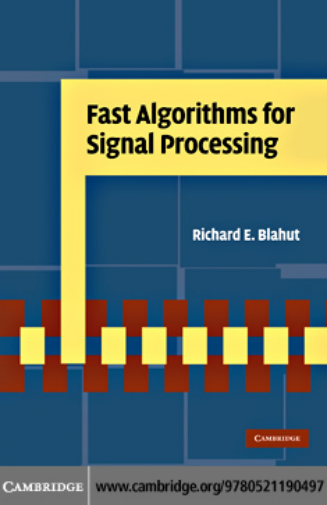

In [164]:
plot_pdf(doc[0], dpi=100)

## Polynomials

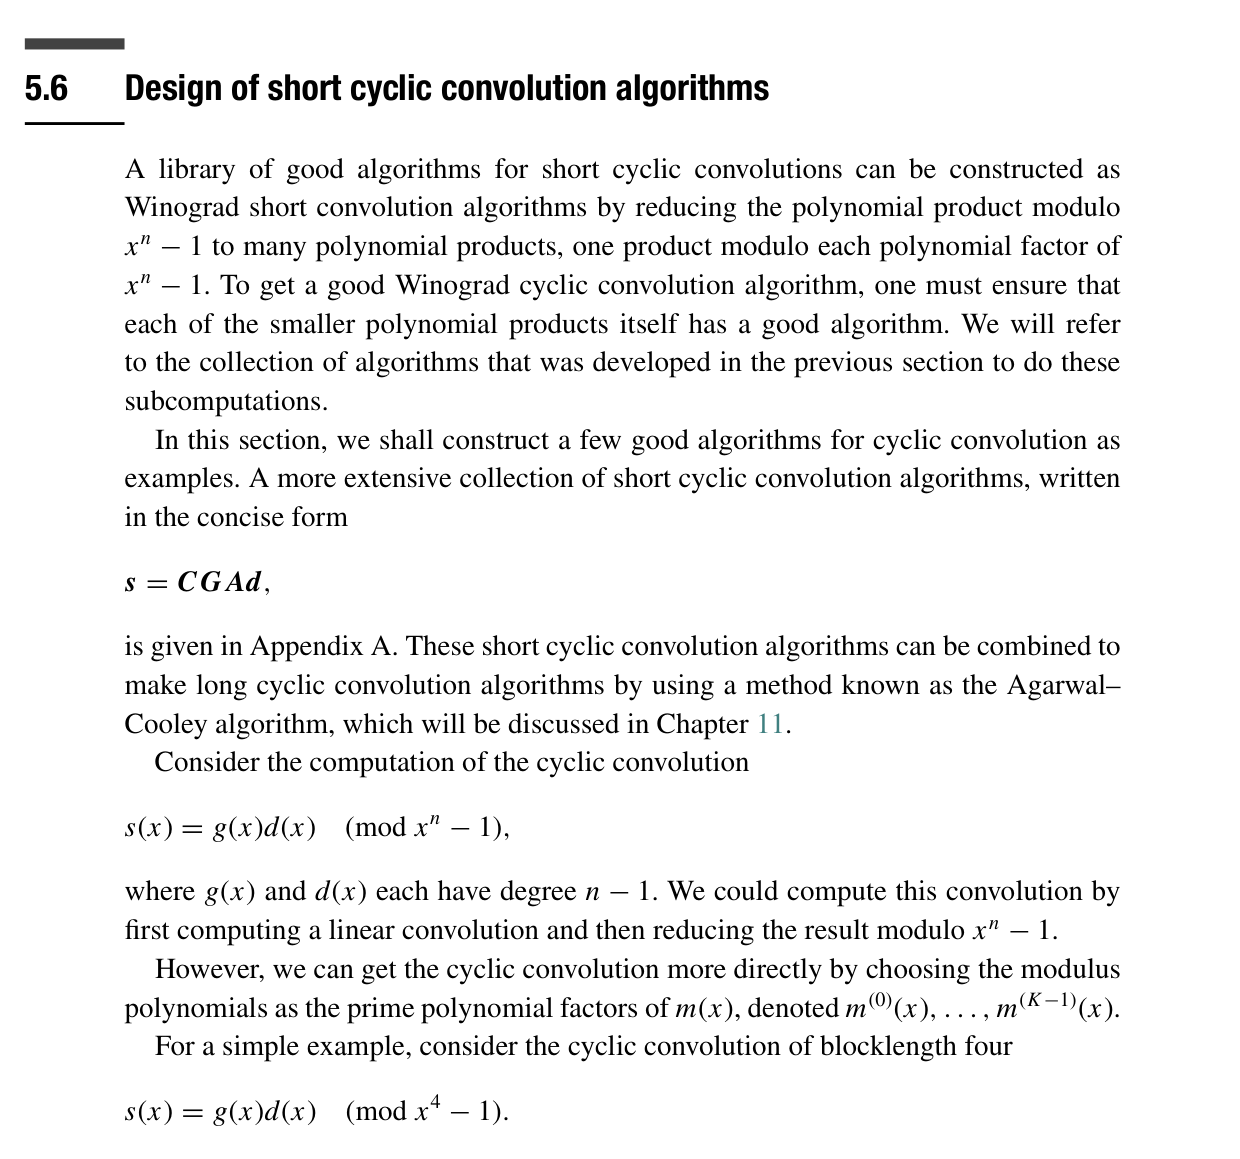

In [165]:
plot_pdf(doc[186], [.24, .85])

Size of vectors

In [166]:
d_num = 4
g_num = 4

Example of vectors for the convolution

In [167]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3, 4] [1, 2, 3, 4]


Polynomial degree

In [168]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

3 3


In [169]:
x = sy.symbols("x")
x

x

In [170]:
di = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
di

Matrix([
[d_0],
[d_1],
[d_2],
[d_3]])

In [171]:
gi = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
gi

Matrix([
[g_0],
[g_1],
[g_2],
[g_3]])

In [172]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d_0 + d_1*x + d_2*x**2 + d_3*x**3

In [173]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g_0 + g_1*x + g_2*x**2 + g_3*x**3

In [174]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2 + d_3*x**3)*(g_0 + g_1*x + g_2*x**2 + g_3*x**3)

## Factor

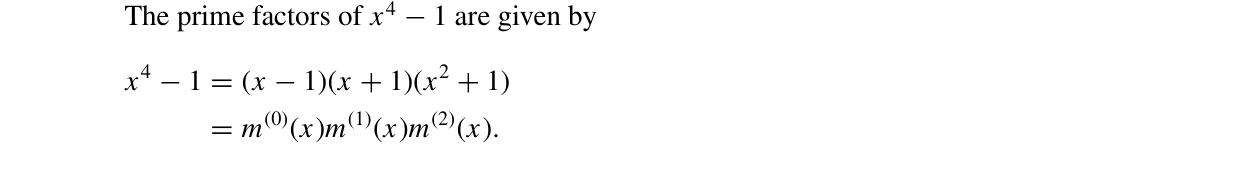

In [175]:
plot_pdf(doc[186], [.85, .95])

In [176]:
mk = sy.Matrix([x-1, x+1, x**2+1])
mk

Matrix([
[   x - 1],
[   x + 1],
[x**2 + 1]])

## Remainders of input polynomials

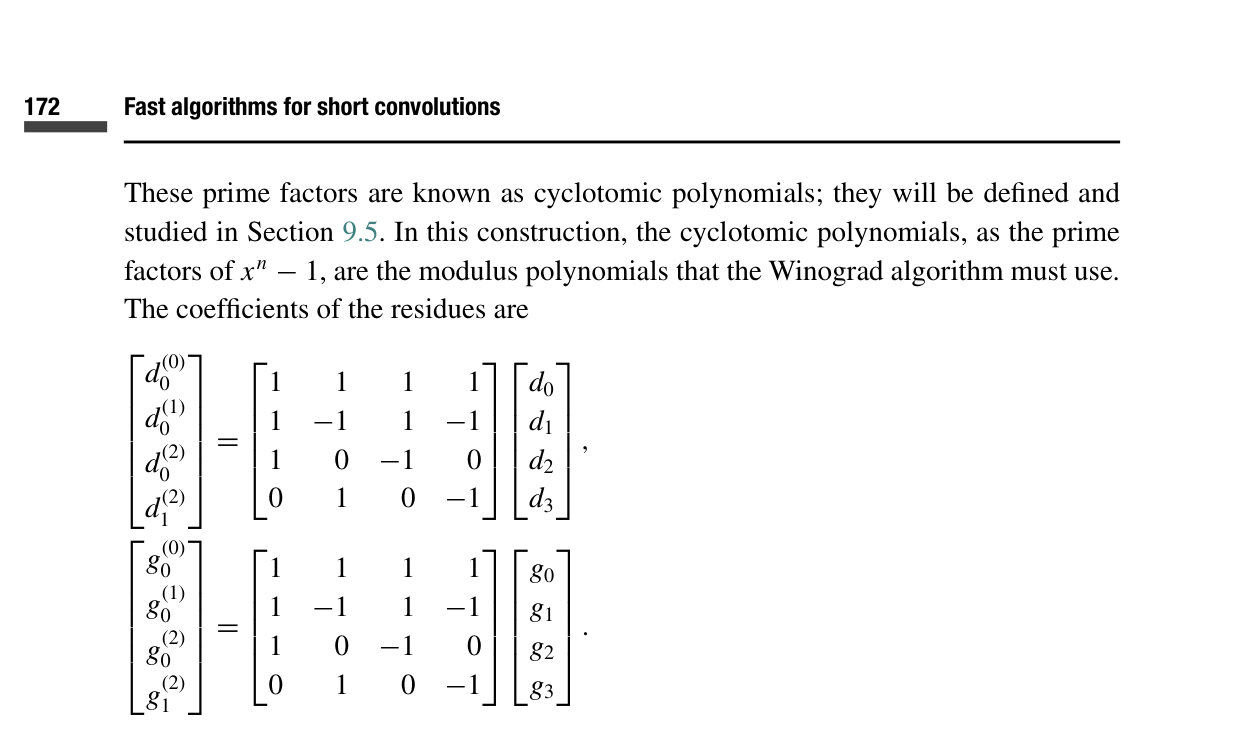

In [177]:
plot_pdf(doc[187], [0, .39])

$d_k$ and $g_k$ pass by a polynomial division and we only get the remainder

In [178]:
dk = sy.Matrix([sy.rem(dx, q, domain ='ZZ') for q in mk])
dk

Matrix([
[    d_0 + d_1 + d_2 + d_3],
[    d_0 - d_1 + d_2 - d_3],
[d_0 + d_1*x - d_2 - d_3*x]])

In [179]:
a0_lst = [[d.coeff(c, 1) for c in di] for d in dk[:-1]]
sy.Matrix(a0_lst)

Matrix([
[1,  1, 1,  1],
[1, -1, 1, -1]])

In [180]:
a20_lst = [dk[-1].subs({x:0}).coeff(c, 1) for c in di]
sy.Matrix(a20_lst)

Matrix([
[ 1],
[ 0],
[-1],
[ 0]])

In [181]:
a21_lst = [dk[-1].coeff(c, 1).coeff(x, 1) for c in di]
sy.Matrix(a21_lst)

Matrix([
[ 0],
[ 1],
[ 0],
[-1]])

In [182]:
a0_mtx = sy.Matrix(np.vstack([a0_lst, a20_lst, a21_lst]))
a0_mtx

Matrix([
[1,  1,  1,  1],
[1, -1,  1, -1],
[1,  0, -1,  0],
[0,  1,  0, -1]])

In [183]:
gk = sy.Matrix([sy.rem(gx, q, domain ='ZZ') for q in mk])
gk

Matrix([
[    g_0 + g_1 + g_2 + g_3],
[    g_0 - g_1 + g_2 - g_3],
[g_0 + g_1*x - g_2 - g_3*x]])

In [184]:
b0_lst = [[d.coeff(c, 1) for c in gi] for d in gk[:-1]]
sy.Matrix(b0_lst)

Matrix([
[1,  1, 1,  1],
[1, -1, 1, -1]])

In [185]:
b20_lst = [gk[-1].subs({x:0}).coeff(c, 1) for c in gi]
sy.Matrix(b20_lst)

Matrix([
[ 1],
[ 0],
[-1],
[ 0]])

In [186]:
b21_lst = [gk[-1].coeff(c, 1).coeff(x, 1) for c in gi]
sy.Matrix(b21_lst)

Matrix([
[ 0],
[ 1],
[ 0],
[-1]])

In [187]:
b0_mtx = sy.Matrix(np.vstack([b0_lst, b20_lst, b21_lst]))
b0_mtx

Matrix([
[1,  1,  1,  1],
[1, -1,  1, -1],
[1,  0, -1,  0],
[0,  1,  0, -1]])

## $S^2$ 

$S^2$ development is different, and i don't understand this part yet.

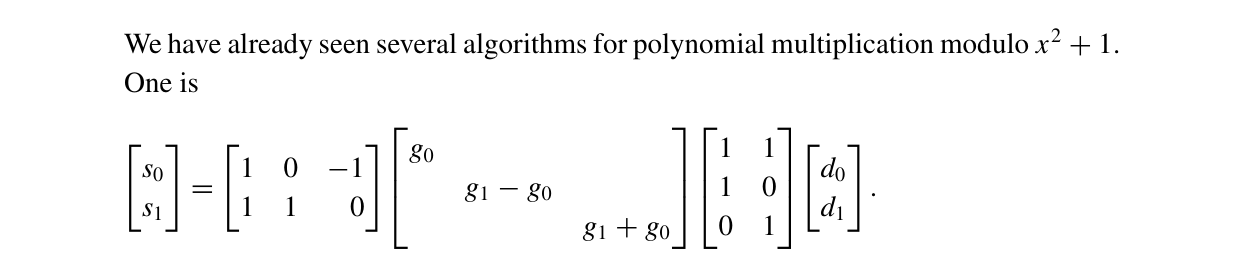

In [188]:
plot_pdf(doc[187], [.38, .52])

Just defining values of matrices

In [189]:
n_cyclic = 2

In [190]:
a2_mtx = sy.Matrix(matrices[n_cyclic]["a"])
a2_mtx

Matrix([
[1,  1],
[1, -1]])

In [191]:
b2_mtx = sy.Matrix(matrices[n_cyclic]["b"])
b2_mtx

Matrix([
[1,  1],
[1, -1]])

In [192]:
g2_mtx = sy.Matrix([sy.Rational(Fraction(matrices[n_cyclic]["g"]))]*(b2_mtx.shape[0]))
g2_mtx

Matrix([
[1/2],
[1/2]])

In [193]:
bg2_mtx = sy.Matrix(np.multiply(g2_mtx, b2_mtx))
bg2_mtx

Matrix([
[1/2,  1/2],
[1/2, -1/2]])

In [194]:
c2_mtx = sy.Matrix(matrices[n_cyclic]["c"])
c2_mtx

Matrix([
[1,  1],
[1, -1]])

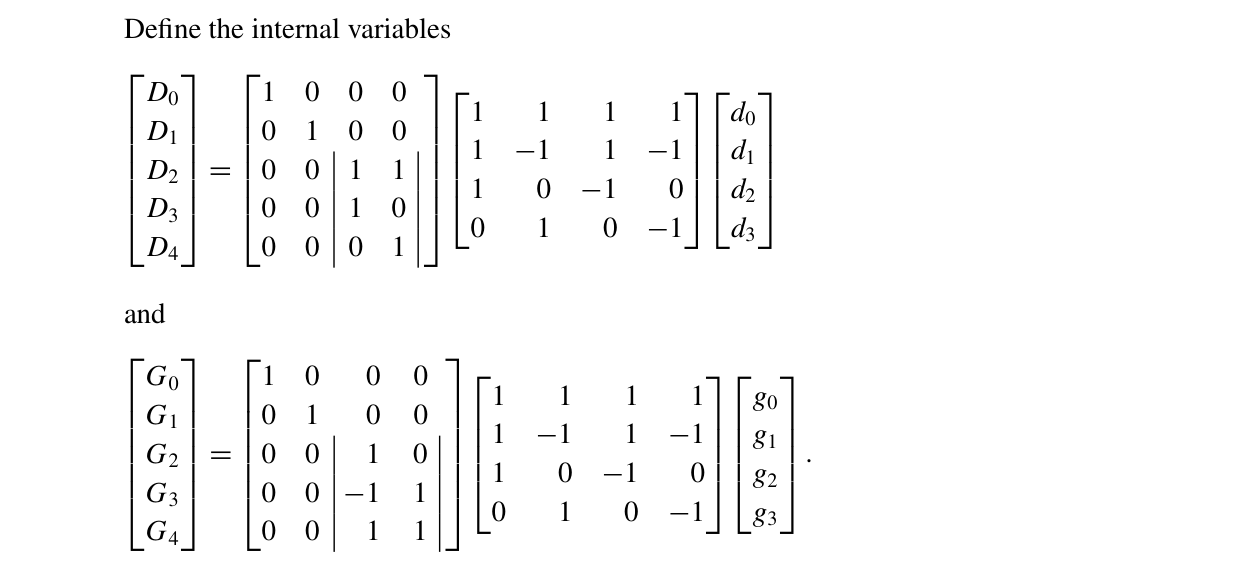

In [195]:
plot_pdf(doc[187], [.52, .82])

In [196]:
a2e_mtx = sy.Matrix(sy.diag(sy.eye(2), a2_mtx))
a2e_mtx

Matrix([
[1, 0, 0,  0],
[0, 1, 0,  0],
[0, 0, 1,  1],
[0, 0, 1, -1]])

In [197]:
a_mtx = a2e_mtx * a0_mtx
a_mtx

Matrix([
[1,  1,  1,  1],
[1, -1,  1, -1],
[1,  1, -1, -1],
[1, -1, -1,  1]])

In [260]:
bg2e_mtx = sy.Matrix(sy.diag(sy.eye(2), bg2_mtx))
bg2e_mtx

Matrix([
[1, 0,   0,    0],
[0, 1,   0,    0],
[0, 0, 1/2,  1/2],
[0, 0, 1/2, -1/2]])

In [226]:
b_mtx = bg2e_mtx * b0_mtx
b_mtx


Matrix([
[  1,    1,    1,    1],
[  1,   -1,    1,   -1],
[1/2,  1/2, -1/2, -1/2],
[1/2, -1/2, -1/2,  1/2]])

## Remainders of (output) inverse polynomial

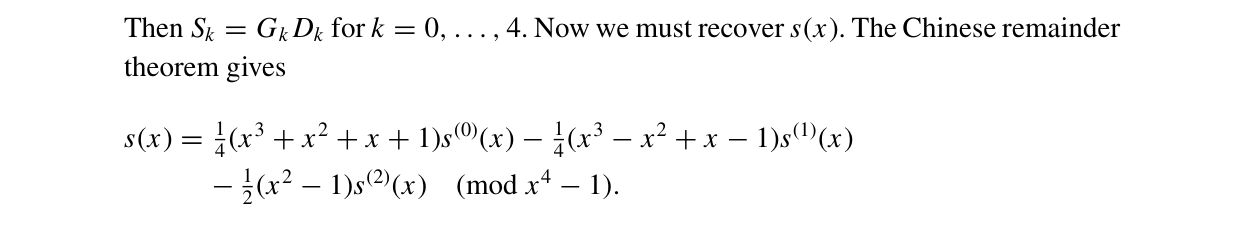

In [200]:
plot_pdf(doc[187], [.82, .95])

$m^{(k)}$ is `mk`
 
$M^{(k)}$ is `mmk`
 
$N^{(k)}$ is `nnk`

In [201]:
mk

Matrix([
[   x - 1],
[   x + 1],
[x**2 + 1]])

In [202]:
mmk = sy.Matrix([sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)])
mmk

Matrix([
[x**3 + x**2 + x + 1],
[x**3 - x**2 + x - 1],
[           x**2 - 1]])

In [203]:
mmk_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]

In [204]:
mmk_quo = sy.Matrix([x[0] for x in mmk_div])
mmk_quo

Matrix([
[x**2 + 2*x + 3],
[x**2 - 2*x + 3],
[             1]])

In [205]:
mmk_rem = sy.Matrix([x[1] for x in mmk_div])
mmk_rem

Matrix([
[ 4],
[-4],
[-2]])

In [206]:
nnk = sy.Matrix([1/z for z in mmk_rem])
nnk

Matrix([
[ 1/4],
[-1/4],
[-1/2]])

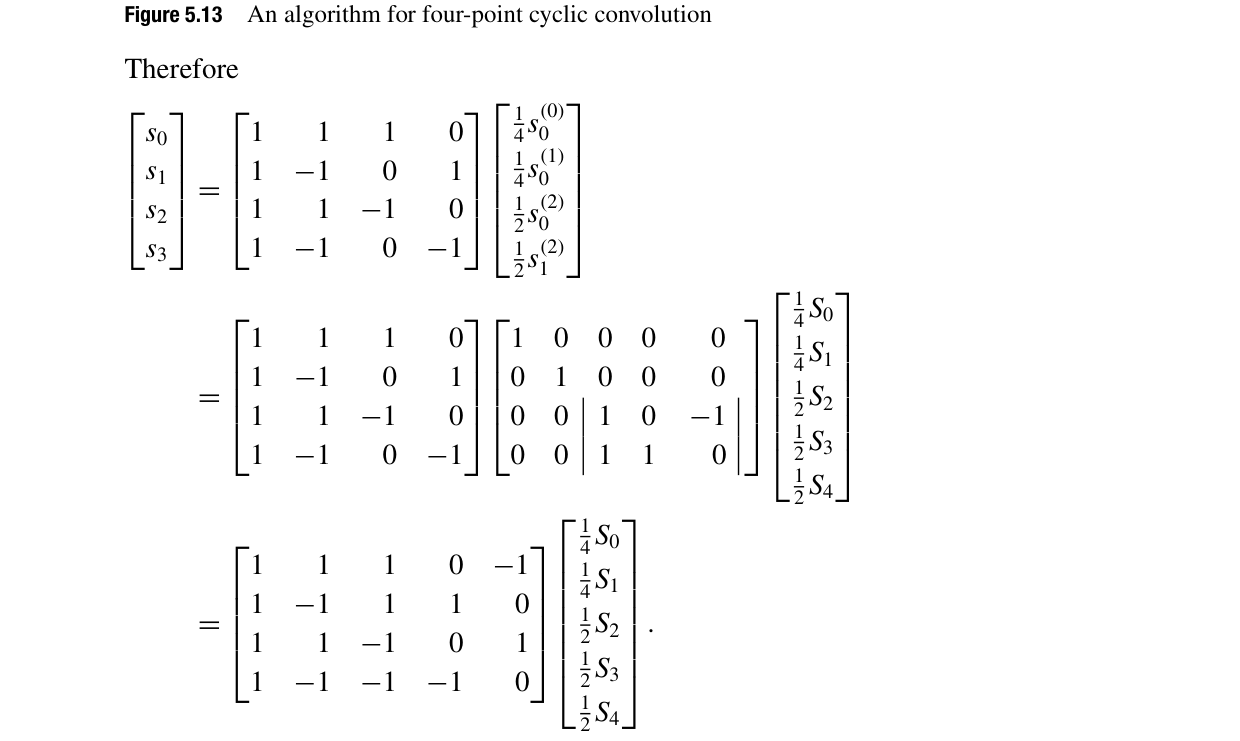

In [207]:
plot_pdf(doc[188], [0.35, .74])

In [208]:
c20_mtx = sy.expand(mmk[-1])
c20_mtx

x**2 - 1

This part, getting $s_{1}^{(2)}$, is much different to 5.3 Winograd example. I believe this is because $s^{(2)}$ is degree $2$, not maximum, different from 5.3 example where $s^{(2)}$ is degree $3$, the maximum degree of the function.

In [209]:
# c21_mtx = sy.rem(np.prod(mk), sy.expand(c20_mtx*x), domain ='ZZ')
c21_mtx = (c20_mtx*x).expand()
c21_mtx

x**3 - x

## Put all together

Important: the signals of the $C$ matrix are inverted.
I multiply $N^{(k)}$ matrix by $G$ and not by $C$.
In books the constants of $N^{(k)}$ go to $G$, and the signals go to $C$.
In this implementation all go to $G$.

In [210]:
mmk_new = sy.Matrix(mmk[:-1] + [c20_mtx] + [c21_mtx])
mmk_new

Matrix([
[x**3 + x**2 + x + 1],
[x**3 - x**2 + x - 1],
[           x**2 - 1],
[           x**3 - x]])

In [211]:
c0_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk_new] for c in range(len(np.prod(mk).as_poly().all_coeffs())-1)])
c0_mtx

Matrix([
[1, -1, -1,  0],
[1,  1,  0, -1],
[1, -1,  1,  0],
[1,  1,  0,  1]])

In [212]:
c2e_mtx = sy.Matrix(sy.diag(sy.eye(2), c2_mtx))
c2e_mtx

Matrix([
[1, 0, 0,  0],
[0, 1, 0,  0],
[0, 0, 1,  1],
[0, 0, 1, -1]])

In [213]:
c_mtx = c0_mtx * c2e_mtx
c_mtx

Matrix([
[1, -1, -1, -1],
[1,  1, -1,  1],
[1, -1,  1,  1],
[1,  1,  1, -1]])

In [214]:
g_mtx = sy.diag(*(nnk[:-1] + [nnk[-1]]*(max(b_mtx.shape) - len(nnk[:-1]))))
g_mtx

Matrix([
[1/4,    0,    0,    0],
[  0, -1/4,    0,    0],
[  0,    0, -1/2,    0],
[  0,    0,    0, -1/2]])

In [227]:
bg_mtx = sy.diag(*(g_mtx*b_mtx*sy.Matrix(gi)).tolist())
bg_mtx

Matrix([
[g_0/4 + g_1/4 + g_2/4 + g_3/4,                              0,                              0,                              0],
[                            0, -g_0/4 + g_1/4 - g_2/4 + g_3/4,                              0,                              0],
[                            0,                              0, -g_0/4 - g_1/4 + g_2/4 + g_3/4,                              0],
[                            0,                              0,                              0, -g_0/4 + g_1/4 + g_2/4 - g_3/4]])

In [257]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, di)
s

Matrix([
[1, -1, -1, -1],
[1,  1, -1,  1],
[1, -1,  1,  1],
[1,  1,  1, -1]])*Matrix([
[g_0/4 + g_1/4 + g_2/4 + g_3/4,                              0,                              0,                              0],
[                            0, -g_0/4 + g_1/4 - g_2/4 + g_3/4,                              0,                              0],
[                            0,                              0, -g_0/4 - g_1/4 + g_2/4 + g_3/4,                              0],
[                            0,                              0,                              0, -g_0/4 + g_1/4 + g_2/4 - g_3/4]])*Matrix([
[1, -1,  1,  1],
[1, -1,  1, -1],
[1,  1, -1, -1],
[1, -1, -1,  1]])*Matrix([
[d_0],
[d_1],
[d_2],
[d_3]])

This is the same cyclic convolution of $4\times4$ of "Appendix A A collection of cyclic convolution algorithms"

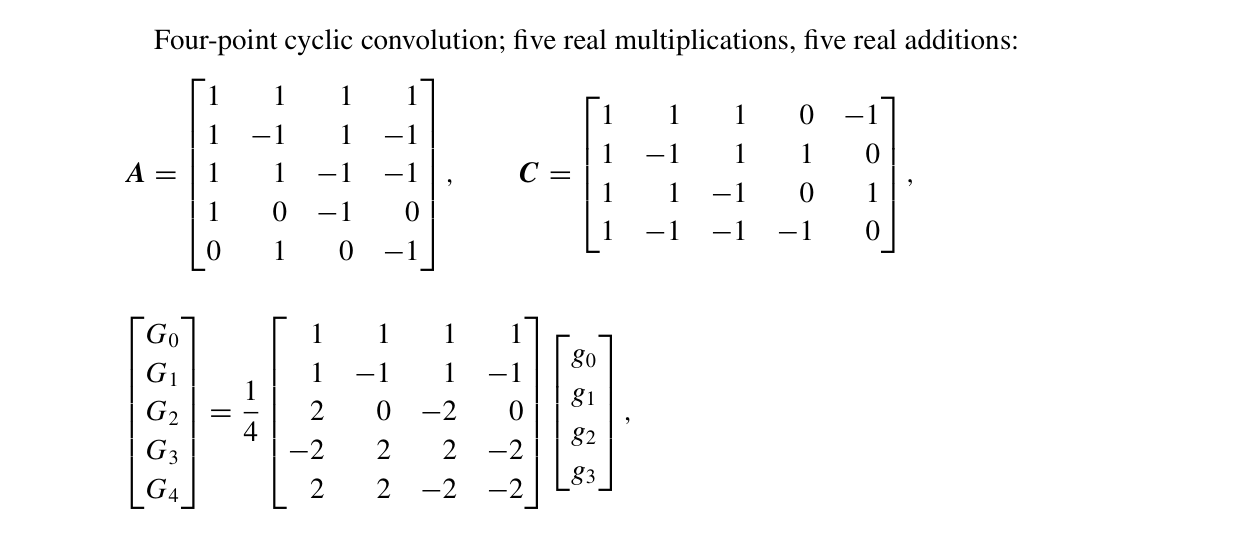

In [217]:
plot_pdf(doc[443], [0.21, .5])

## Example

In [218]:
subs = {k[0]: v for k, v in zip(di.tolist()+gi.tolist(), d_values + g_values)}
subs

{d_0: 1, d_1: 2, d_2: 3, d_3: 4, g_0: 1, g_1: 2, g_2: 3, g_3: 4}

In [258]:
si = s.subs(subs)
si

Matrix([
[1, -1, -1, -1],
[1,  1, -1,  1],
[1, -1,  1,  1],
[1,  1,  1, -1]])*Matrix([
[5/2,   0, 0, 0],
[  0, 1/2, 0, 0],
[  0,   0, 1, 0],
[  0,   0, 0, 0]])*Matrix([
[1, -1,  1,  1],
[1, -1,  1, -1],
[1,  1, -1, -1],
[1, -1, -1,  1]])*Matrix([
[1],
[2],
[3],
[4]])

In [234]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_0*g_2*x**2 + d_0*g_3*x**3 + d_1*g_0*x + d_1*g_1*x**2 + d_1*g_2*x**3 + d_1*g_3*x**4 + d_2*g_0*x**2 + d_2*g_1*x**3 + d_2*g_2*x**4 + d_2*g_3*x**5 + d_3*g_0*x**3 + d_3*g_1*x**4 + d_3*g_2*x**5 + d_3*g_3*x**6

Let's compare the output polynomial matrix from direct and winograd method

In [235]:
symmetrical_cyclic_convolution(di, gi)

Matrix([
[d_0*g_0 + d_1*g_3 + d_2*g_2 + d_3*g_1],
[d_0*g_1 + d_1*g_0 + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*g_1 + d_2*g_0 + d_3*g_3],
[d_0*g_3 + d_1*g_2 + d_2*g_1 + d_3*g_0]])

In [259]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, di, evaluate=True)
se

Matrix([
[d_0*g_0 + d_1*(-g_0/2 + g_1/2 - g_2/2 - g_3/2) + d_2*g_2 + d_3*g_3],
[ d_0*g_1 + d_1*(g_0/2 - g_1/2 - g_2/2 - g_3/2) + d_2*g_3 + d_3*g_2],
[d_0*g_2 + d_1*(-g_0/2 - g_1/2 - g_2/2 + g_3/2) + d_2*g_0 + d_3*g_1],
[d_0*g_3 + d_1*(-g_0/2 - g_1/2 + g_2/2 - g_3/2) + d_2*g_1 + d_3*g_0]])

Comparing numerical outputs from direct and winograd method

In [223]:
sy.Matrix(symmetrical_cyclic_convolution(d_values, g_values))

Matrix([
[26],
[28],
[26],
[20]])

In [252]:
se.subs(subs)

Matrix([
[25],
[-1],
[-4],
[ 0]])